<a href="https://www.kaggle.com/code/poeticmage/zero-shot-learning-zsl?scriptVersionId=313511068" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Zero-Shot Learning (ZSL)

#### Add The Citation: P. Mukhopadhyay and D. R. Kisku, "Zero-Shot Learning from scratch (ZFS): Lightweight Stacked Encoder-Only Transformers," in Proc. 6th Int. Conf. on Computer Vision and Robotics (CVR), 2026.
<p>The Awa2 Dataset is used mainly in zero shot learning. This notebook presents how one should prepare and upload the data before training on an Imagenet pretrained resnet backbone with a CLIP based pipeline</p>
<h6>Reference: C. H. Lampert, H. Nickisch, and S. Harmeling. "Learning To Detect Unseen Object Classes by Between-Class Attribute Transfer". In CVPR, 2009 </h6>
<h6>Lampert, C. H., Nickisch, H., & Harmeling, S. (2009). Learning to detect unseen object classes by between-class attribute transfer. CVPR.</h6>

### Upload dependencies,libraries, Install, Import
<p>We install all libraries and import the necessary functions. The %%capture shuts down all prints. Lightning is an important library that runs some training time functions that come handy. We use pytorch for our Computer Vision task. Just  Note that Pytorch operates with Dynamic Graph (The weight-value graph of the whole process is remade every epoch). Torchvision library is useful in image preprocessing. Transforms.Compose helps in conversion of image pixels to float as well as other augmentation like Clahe and Jitters. torch.utils.data gives us Dataset, that helps us to prepare our dataset in a class as they run typical functions like __len__ and __getitem__ , and DataLoader that finally prepares our train_loader and test_loader </p>
<h6>Note: ALWAYS CHECK FILE NAMES BEFORE USING</h6>

In [1]:
%%capture
import os
! pip install scikit-learn numpy matplotlib pandas lightning torch timm==0.5.4
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import lightning as L
from torchvision import datasets, transforms
import numpy as np
from glob import glob
from PIL import Image
import logging
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

### Declare the transforms
<p>Declare the transforms.Compose because we will use this to convert our image to float type</p>

In [2]:
transform=transforms.Compose([transforms.ToTensor(),])

### Class dataset
<p> Build the Class and invoke the function Dataset from torch.utils.data so that it upload the input and prepares the data for train and test later. We extract image from file, strip and split the file name to get class name and get the corresponding attribute matrix after we have a class to index map. The class is the label index in order as given. Then we return the image, label and respective attribute side by side</p>
<h6>NB: Check the file-paths everytime you copy-paste this block</h6>

In [3]:
class AnimalDataset(Dataset):
    def __init__(self, classes_file_path, transform=None):
        self.transform = transform
        # 50x85 /kaggle/input/datasets/rrebirrth/animals-with-attributes-2
        self.predicate_binary_mat = np.genfromtxt(
            '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix-binary.txt',
            dtype='int'
        )
        self.class_to_index = {}
        with open('/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/classes.txt') as f:
            for idx, line in enumerate(f):
                class_name = line.strip().split('\t')[1]
                self.class_to_index[class_name] = idx
        self.img_paths = []
        self.img_class_indices = [] 
        self.img_attr_vectors = []  
        with open(classes_file_path) as f:
            selected_classes = [line.strip() for line in f]
        for class_name in selected_classes:
            class_index = self.class_to_index[class_name]
            class_attr = self.predicate_binary_mat[class_index]
            folder_path = os.path.join(
                '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages',
                class_name
            )
            for img_path in glob(os.path.join(folder_path, '*.jpg')):
                self.img_paths.append(img_path)
                self.img_class_indices.append(class_index)
                self.img_attr_vectors.append(class_attr)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        attr_vector = torch.tensor(self.img_attr_vectors[idx], dtype=torch.float32)
        class_index = self.img_class_indices[idx]  # true label
        return image, attr_vector, class_index, img_path

### Prepare loaders
<p>Perform some augmentation and prepare the train_loader and test_loader here</p>

In [4]:
def get_data_loaders(train_classes_file, test_classes_file, batch_size=16):
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_dataset = AnimalDataset(train_classes_file, transform=train_transform)
    test_dataset = AnimalDataset(test_classes_file, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, test_loader

### Use loader to build the final loader
<p>Use the above function and file name to upload the final train and test loader</p>


In [5]:
train_loader, test_loader = get_data_loaders(
    '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/trainclasses.txt',
    '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/testclasses.txt',
    batch_size=16
)

### Check loads
<p>Check the size, shape, etc. of your inputs</p>

In [6]:
images,attrs, label, paths = next(iter(train_loader))

print("Images shape:", images.shape)
print("Attributes shape:", label.shape)
print("First image path:", paths[0])

Images shape: torch.Size([16, 3, 224, 224])
Attributes shape: torch.Size([16])
First image path: /kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages/tiger/tiger_10726.jpg


### Visualize data
<p>Get one image, its attribute, and path. Convert to numpy after rearranging the image tensor of 3(C)x224(H)x224(W) to image first, channel later (the way to visualize image) : HxWxC where BxCxHxW are Batch, Channel (3 initially for RGB), Height and Width. Use pyplot imshow for visualization</p>

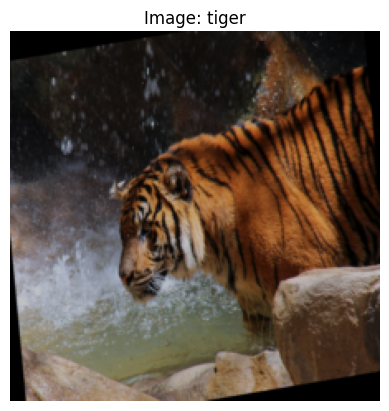

Attribute vector for this image:
[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0]
/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/JPEGImages/tiger/tiger_10726.jpg


In [7]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# Get one image, its attribute, and path
image, attr, label, path = images[0], attrs[0], label[0], paths[0]


image_np = image.permute(1, 2, 0).cpu().numpy()

# Plot the image
plt.imshow(image_np)
plt.axis('off')
plt.title("Image: " + path.split('/')[-2])
plt.show()

# Print the attribute vector (binary: 0/1)
print("Attribute vector for this image:")
print(attr.int().tolist())
print(path)

### Check the first test loader
<p> Check the test loader too with the first instance</p>

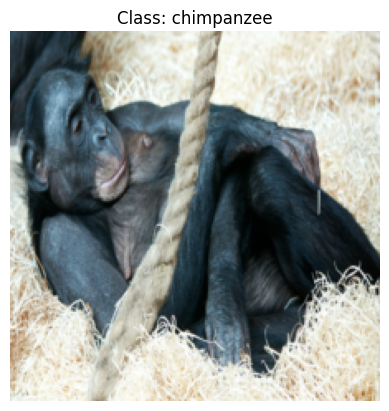

Attribute vector for 'chimpanzee':
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1]


In [8]:
import matplotlib.pyplot as plt

# Get a batch from the train_loader
for images, attrs, label, paths in test_loader:
    for i in range(len(images)):
        image = images[i]
        attr = attrs[i]
        path = paths[i]

        # Convert image to numpy for display
        image_np = image.permute(1, 2, 0).cpu().numpy()

        # Get class name from path (second last folder in path)
        class_name = path.split('/')[-2]

        # Plot image
        plt.imshow(image_np)
        plt.axis('off')
        plt.title(f"Class: {class_name}")
        plt.show()

        # Print attribute vector
        print(f"Attribute vector for '{class_name}':\n{attr.int().tolist()}")
        
        break
    break

### Visualize Predicate Matrix

 Display the full attribute matrix image for reference.

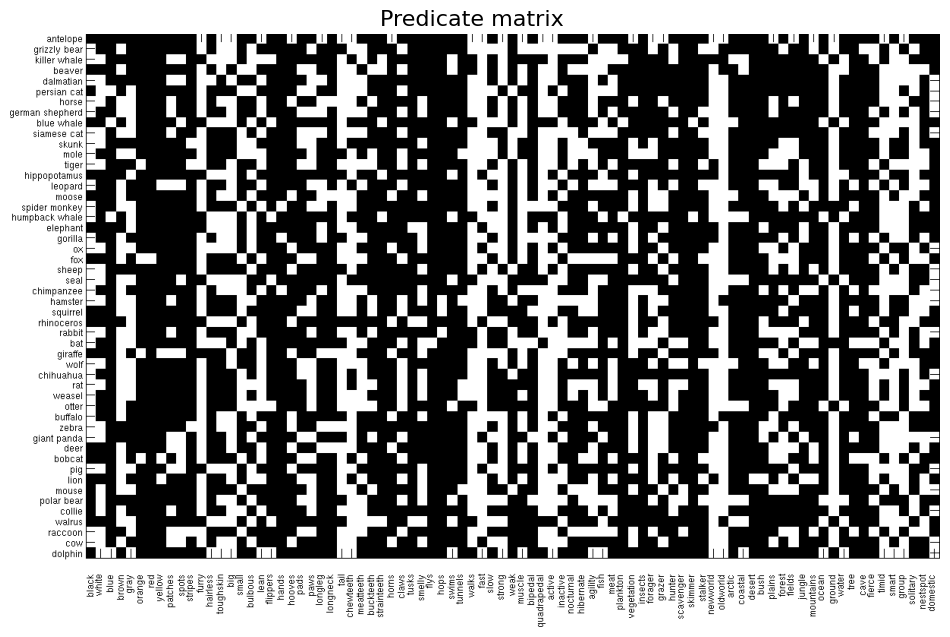

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = '/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix.png'
image = Image.open(img_path)

plt.figure(figsize=(12, 10))  # Width x Height in inches /kaggle/input/datasets/rrebirrth/animals-with-attributes-2
plt.imshow(image)
plt.axis('off')
plt.title("Predicate matrix ", fontsize=16)
plt.show()

### Load Image net from Resnet 50 weights
We would use an Imagenet-pretrained Resnet backbone. Load that

In [10]:
%%capture
from torchvision.models import resnet50, ResNet50_Weights
weights = ResNet50_Weights.IMAGENET1K_V1
resnet = resnet50(weights=weights)
! pip uninstall tensorflow jax jaxlib -y
import sys
import os
import warnings

### MAIN MODEL

We have our entire Zero-shot model in this cell. It requires passing our raw images through the resnet imagenet backbone to obtain projections of dimension Bx2048. We pass them through a self made weak MLP to generate embeddings of size Bx512. We pass our attribute vectors through another MLP to get embeddings of Cx512. This becomes our shared embedding space. Images are projected through that to obtain a CLIP styled logit.

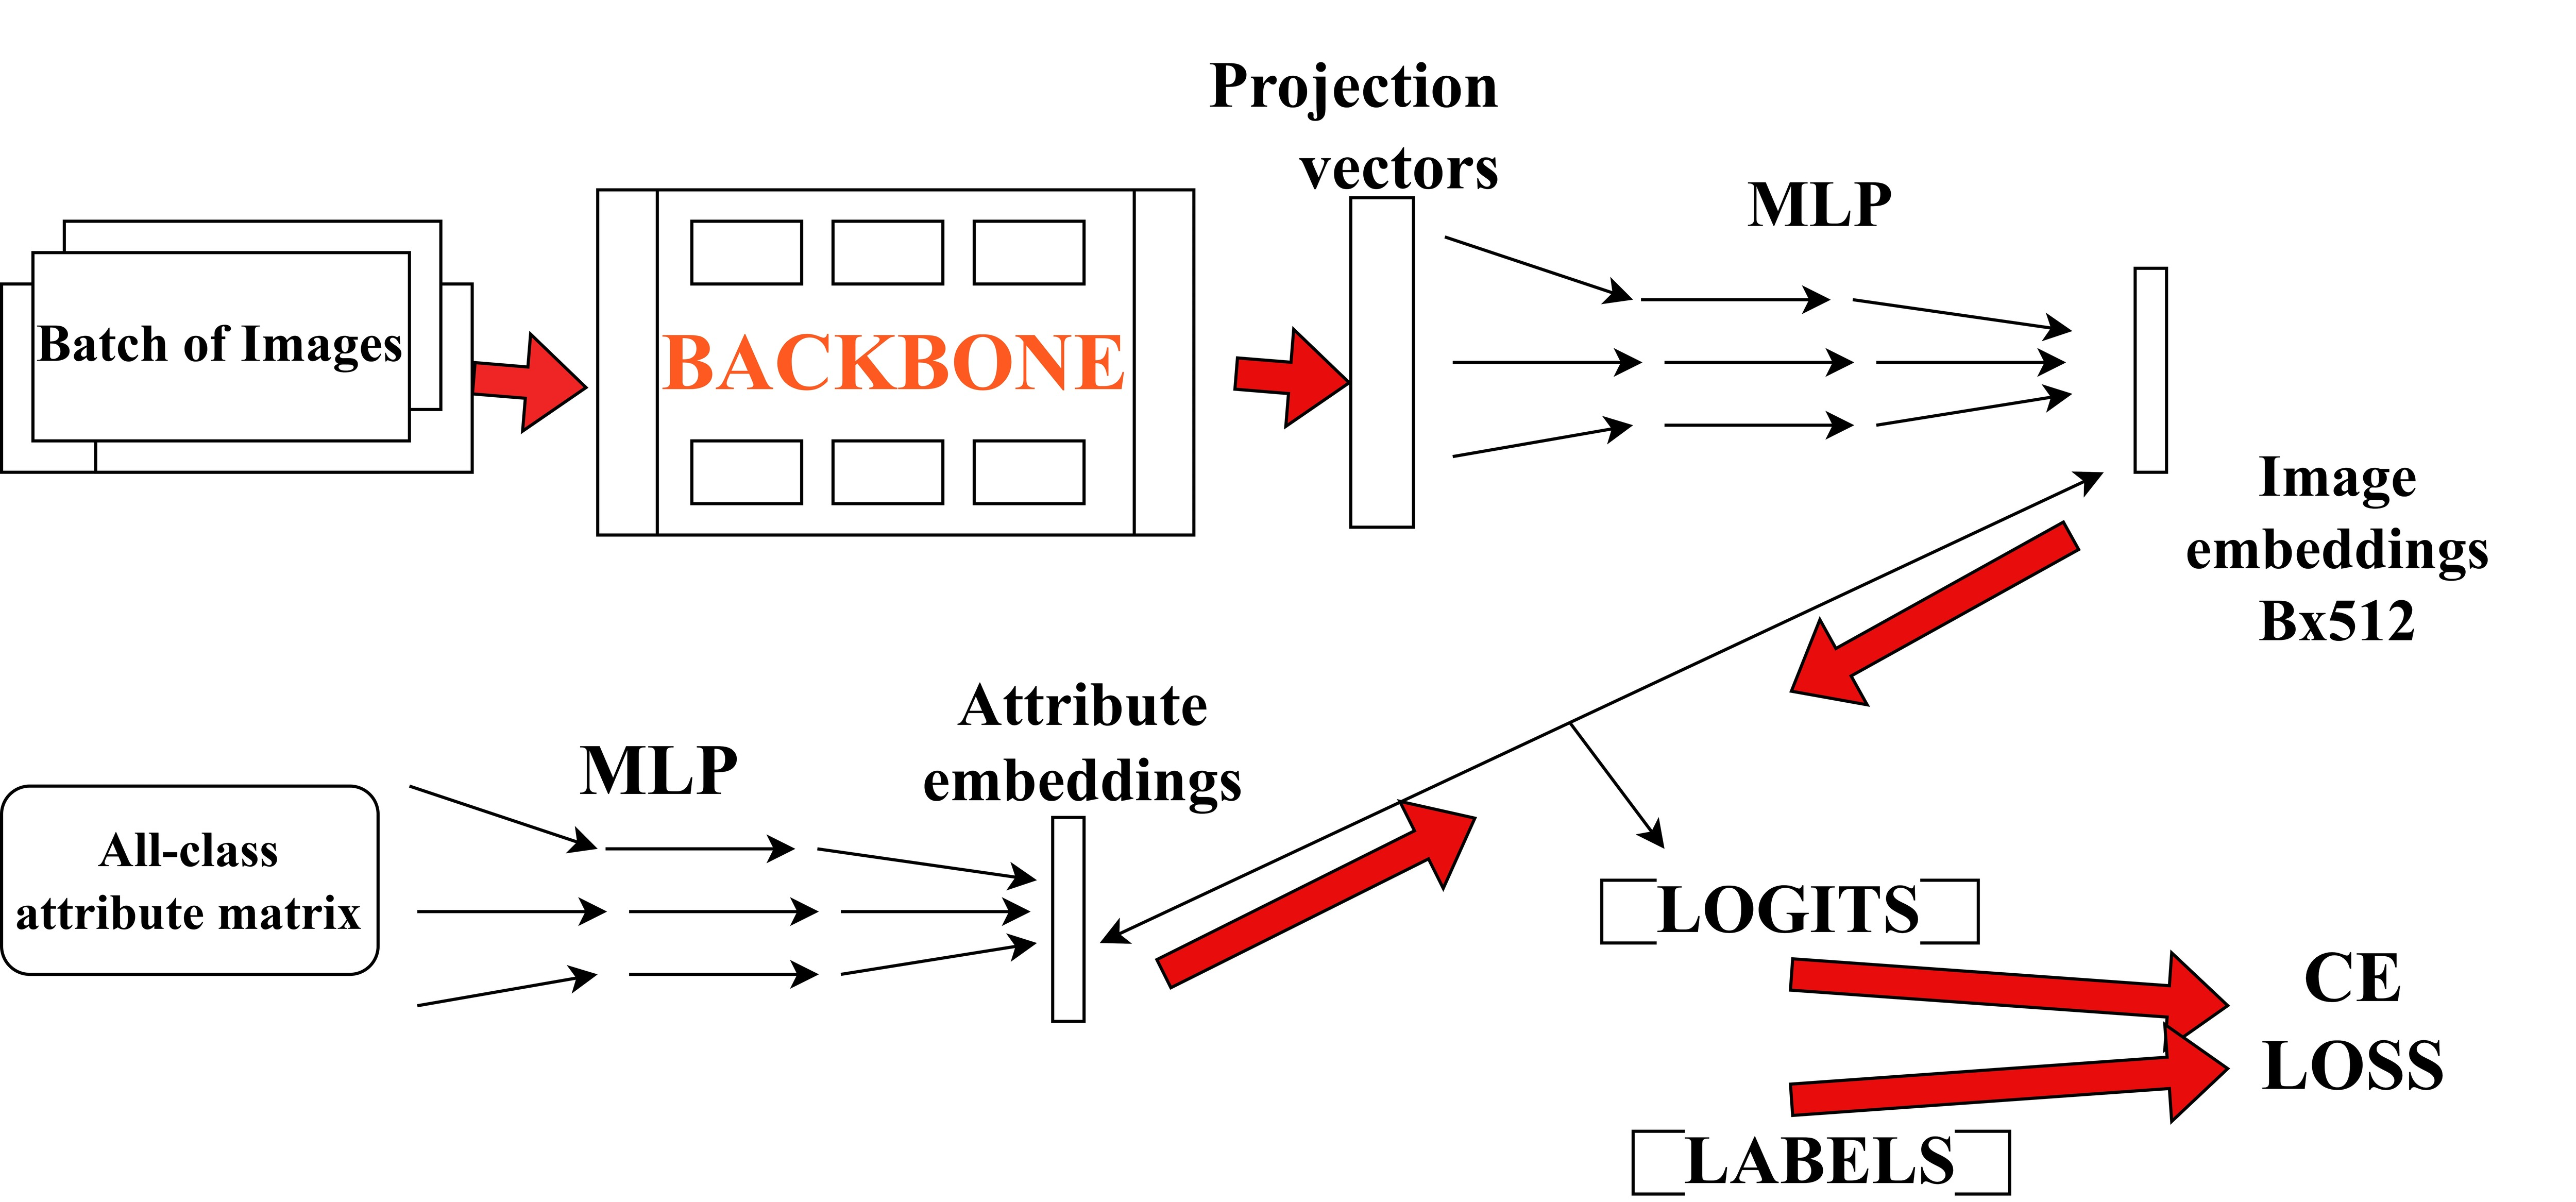
### Fig 1. The training pipeline of our ZSL architecture 

##### Labels serve only as tags here. They carry no intrinsic character

The losses that were included were primarily the Cross Entropy loss, Cosine Similarity loss (The dot product itself is the cosine projection and 1 - that is the loss). We use KL Divergence as a bleak regularizer. You can tweak the learning rate and weight decay. Cosine Annealing Schedular is used.

Make sure you turn off all warnings and progress bar. This gave me horrible errors (IOPub Error)
[Read this Discussion to know more]("https://www.kaggle.com/discussions/general/693469")

We use Lightning Module. The **Map** in on_validation_start is used to relabel test dataset as the new indices will be altered, we need to remap them to get accurate answer. This is a CZSL (Conventional Zero shot learning) where test classes are measured against all test classes only. In GZSL (Xian et al.) the test classes are measured against all class attribute, yielding lower accuracy.


In [11]:
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)

class LocalAttentionZSLNet(L.LightningModule):
    def __init__(self, all_class_attrs, backbone=None,
                 img_size=224, patch_size=16, embed_dim=2048,
                 attr_dim=85, shared_dim=512):
        super().__init__()
        self.save_hyperparameters(ignore=["all_class_attrs", "backbone"])      
        L.seed_everything(42)

        self.backbone = backbone if backbone is not None else resnet50(weights=None)
        # remove classifier
        self.backbone.fc = nn.Identity()
        #  freeze early layers (stability)
        for name, param in self.backbone.named_parameters():
            if "layer4" not in name:  
                param.requires_grad = False
        backbone_dim = 2048  # resnet50 output
        self.img_proj = nn.Sequential( # MLP in the Fig 1.
            nn.Linear(embed_dim, shared_dim * 2),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(shared_dim * 2, shared_dim),
            nn.Dropout(0.13),
            nn.LayerNorm(shared_dim)
        )
        self.attr_proj = nn.Sequential( # MLP in the Fig 1. of Markdown above
            nn.Linear(attr_dim, shared_dim * 2),
            nn.LayerNorm(shared_dim * 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(shared_dim * 2, shared_dim * 2),
            nn.LayerNorm(shared_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(shared_dim * 2, shared_dim),
            nn.LayerNorm(shared_dim)
        )
        self.register_buffer("all_class_attrs", all_class_attrs)
        self.temperature = nn.Parameter(torch.tensor(1.0))
        self.eval_history = []
        #KL Divergence Scheduling 
        self.max_kl_weight = 0.01
        self.kl_warmup_epochs = 10

    def forward(self, x):
        feat = self.backbone(x)  # [B, 2048]
        img_embed = F.normalize(self.img_proj(feat), dim=-1)
        return img_embed

    def training_step(self, batch, batch_idx):
        images, attrs, labels, paths = batch
        img_embed = self(images)
        class_attr_embeds = F.normalize(self.attr_proj(self.all_class_attrs), dim=-1)  # [C, D]
        logits = torch.matmul(F.normalize(img_embed, dim=-1), class_attr_embeds.T) / self.temperature.clamp(min=0.01)
        ce_loss = F.cross_entropy(logits, labels, label_smoothing=0.05)
        # KL Divergence regularization
        log_probs = F.log_softmax(logits, dim=-1)
        target_probs = F.one_hot(labels, num_classes=logits.size(-1)).float()
        target_probs = target_probs * (1 - 0.05) + 0.05 / logits.size(-1)  # label smoothing
        kl_loss = F.kl_div(log_probs, target_probs, reduction="batchmean")
        # Attribute alignment loss
        target_attrs = F.normalize(self.all_class_attrs[labels], dim=-1)
        attr_embed = F.normalize(self.attr_proj(target_attrs), dim=-1)
        img_embed_aligned = F.normalize(img_embed, dim=-1)
        cosine_sim = F.cosine_similarity(img_embed_aligned, attr_embed, dim=-1)
        attr_loss = 1 - cosine_sim.mean()
        #Contrastive loss
        sims = torch.matmul(F.normalize(img_embed, dim=-1), F.normalize(attr_embed, dim=-1).T)
        targets = torch.arange(sims.size(0), device=sims.device)
        loss_i2a = F.cross_entropy(sims / 0.07, targets)
        loss_a2i = F.cross_entropy(sims.T / 0.07, targets)
        contrastive_loss = (loss_i2a + loss_a2i) / 2
        # Combined loss
        kl_weight = min(self.max_kl_weight, self.max_kl_weight * self.current_epoch / self.kl_warmup_epochs)
        loss = ce_loss + 0.01 * attr_loss + kl_weight * kl_loss + 0.2* contrastive_loss
        acc = (logits.argmax(dim=1) == labels).float().mean() * 100
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=False)
        torch.cuda.empty_cache()
        return loss


    def on_validation_start(self):
        if hasattr(self, '_val_cache_ready'):
            return
        device = self.device
        test_loader = self.trainer.val_dataloaders[1]
        all_labels = torch.cat([labels for _, _, labels,_ in test_loader])
        test_class_indices = torch.unique(all_labels).to(device)

        self.test_label_map = torch.full((test_class_indices.max().item() + 1,), -1, dtype=torch.long, device=device)
        self.test_label_map[test_class_indices] = torch.arange(len(test_class_indices), device=device)

        selected_attrs = self.all_class_attrs[test_class_indices].to(device)
        self.test_class_attr_embeds = F.normalize(self.attr_proj(selected_attrs), dim=-1).T
        self._val_cache_ready = True

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        if dataloader_idx != 1:
            return
        if dataloader_idx == 1:
            images, _, labels,_ = batch
            img_embeds = self(images)
            mapped_labels = self.test_label_map[labels]
            logits = torch.matmul(img_embeds, self.test_class_attr_embeds)/self.temperature.clamp(min=0.01)
            preds = logits.argmax(dim=1)
            acc = (preds == mapped_labels).float().mean() * 100
            self.log("test_eval_acc", acc, on_epoch=True, prog_bar=False)

    
    def on_validation_epoch_end(self):
        print("Evaluation starts ")
        train_acc = self.trainer.callback_metrics.get("train_acc")
        test_acc = self.trainer.callback_metrics.get("test_eval_acc/dataloader_idx_1")
        train_loss = self.trainer.callback_metrics.get("train_loss")
    
        train_val = train_acc.item() if train_acc is not None else None
        test_val = test_acc.item() if test_acc is not None else None
        loss_val = train_loss.item() if train_loss is not None else None
    
        if train_val is not None:
            print(f"[Epoch {self.current_epoch}] Train eval acc: {train_val:.2f}%")
        if test_val is not None:
            print(f"[Epoch {self.current_epoch}] Test eval acc: {test_val:.2f}%")
        if loss_val is not None:
            print(f"[Epoch {self.current_epoch}] Train loss: {loss_val:.4f}")    
        log_dir = "epoch_accuracy_logs"
        os.makedirs(log_dir, exist_ok=True)
        log_path = os.path.join(log_dir, "accuracy_log.csv")
        if not os.path.exists(log_path):
            with open(log_path, "w") as f:
                f.write("epoch,train_loss,train_eval_acc,test_eval_acc\n")
        with open(log_path, "a") as f:
            f.write(f"{self.current_epoch},{loss_val},{train_val},{test_val}\n")



    

    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=1e-6, weight_decay=8e-1)
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=5, T_mult=2),
            "interval": "epoch"
        }
        return [optimizer], [scheduler]


    
    @torch.no_grad()
    def predict(self, image, class_attrs=None):
        self.eval()
        img_embed = self(image)
        if class_attrs is None:
            class_attrs = self.all_class_attrs
        class_embed = F.normalize(self.attr_proj(class_attrs), dim=-1)
        similarity = torch.matmul(class_embed, img_embed.T).squeeze(1)
        predicted_class = similarity.argmax().item()
        return predicted_class, similarity




### Model Initialization and Training
 This is where you pass the all class attribute and write your trainer.fit. 

In [12]:
import numpy as np
from pytorch_lightning.loggers import CSVLogger
all_class_attributes = torch.tensor(
    np.genfromtxt('/kaggle/input/datasets/rrebirrth/animals-with-attributes-2/Animals_with_Attributes2/predicate-matrix-binary.txt', dtype='int'),
    dtype=torch.float32
)
logger = CSVLogger("logs/", name="zsl_training")


print("Model starts")

model = LocalAttentionZSLNet(all_class_attrs=all_class_attributes,backbone=resnet)

trainer = L.Trainer(
    max_epochs=15,
    accelerator='auto',
    enable_model_summary=False,
    logger=logger,
    enable_progress_bar=False

)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=[test_loader, test_loader])
print("done")

INFO:pytorch_lightning.utilities.rank_zero:Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model 

Model starts
Evaluation starts 
Evaluation starts 
[Epoch 0] Test eval acc: 9.25%
Evaluation starts 
[Epoch 1] Train eval acc: 3.51%
[Epoch 1] Test eval acc: 13.94%
[Epoch 1] Train loss: 4.4770
Evaluation starts 
[Epoch 2] Train eval acc: 6.27%
[Epoch 2] Test eval acc: 25.07%
[Epoch 2] Train loss: 4.4402
Evaluation starts 
[Epoch 3] Train eval acc: 10.32%
[Epoch 3] Test eval acc: 27.54%
[Epoch 3] Train loss: 4.3873
Evaluation starts 
[Epoch 4] Train eval acc: 15.44%
[Epoch 4] Test eval acc: 29.46%
[Epoch 4] Train loss: 4.3315
Evaluation starts 
[Epoch 5] Train eval acc: 18.86%
[Epoch 5] Test eval acc: 38.74%
[Epoch 5] Train loss: 4.2996
Evaluation starts 
[Epoch 6] Train eval acc: 28.17%
[Epoch 6] Test eval acc: 41.95%
[Epoch 6] Train loss: 4.2017
Evaluation starts 
[Epoch 7] Train eval acc: 41.58%
[Epoch 7] Test eval acc: 41.56%
[Epoch 7] Train loss: 4.0343
Evaluation starts 
[Epoch 8] Train eval acc: 49.40%
[Epoch 8] Test eval acc: 41.93%
[Epoch 8] Train loss: 3.9127
Evaluation start

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


done


### View Training Log

 Loads training log CSV (`accuracy_log.csv`) as a DataFrame.


In [13]:


import pandas as pd

accuracy_df = pd.read_csv("epoch_accuracy_logs/accuracy_log.csv")
print(accuracy_df)
print("Training Done ")

    epoch  train_loss  train_eval_acc  test_eval_acc
0       0         NaN             NaN            NaN
1       0         NaN             NaN       9.248389
2       1    4.476982        3.510565      13.944166
3       2    4.440187        6.272868      25.068003
4       3    4.387268       10.317434      27.544739
5       4    4.331452       15.436596      29.463135
6       5    4.299596       18.858160      38.740158
7       6    4.201684       28.173517      41.947029
8       7    4.034330       41.576294      41.560486
9       8    3.912721       49.395126      41.932713
10      9    3.830841       53.248508      42.219040
11     10    3.774421       55.466923      42.032928
12     11    3.734901       57.194187      42.390839
13     12    3.707369       58.390743      42.233356
14     13    3.689524       58.407227      41.732285
15     14    3.679957       58.997265      42.677166
Training Done 


### Accuracy Plot

 Plots `train_eval_acc` and `test_eval_acc` across epochs.
- X-axis: Epoch  
- Y-axis: Accuracy (%)  
- Blue → Train accuracy  
- Red → Test (ZSL) accuracy


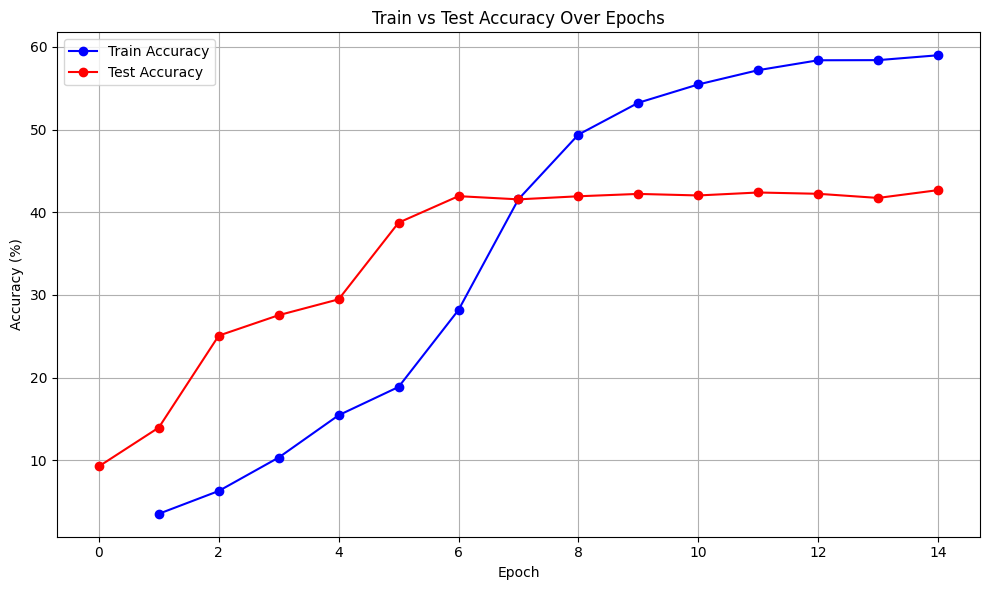

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
accuracy_df = pd.read_csv("epoch_accuracy_logs/accuracy_log.csv")
plt.figure(figsize=(10, 6))
plt.plot(accuracy_df["epoch"], accuracy_df["train_eval_acc"], label="Train Accuracy", color="blue", marker='o')
plt.plot(accuracy_df["epoch"], accuracy_df["test_eval_acc"], label="Test Accuracy", color="red", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch        Train Loss:
    epoch  train_loss
2       1    4.476982
3       2    4.440187
4       3    4.387268
5       4    4.331452
6       5    4.299596
7       6    4.201684
8       7    4.034330
9       8    3.912721
10      9    3.830841
11     10    3.774421
12     11    3.734901
13     12    3.707369
14     13    3.689524
15     14    3.679957


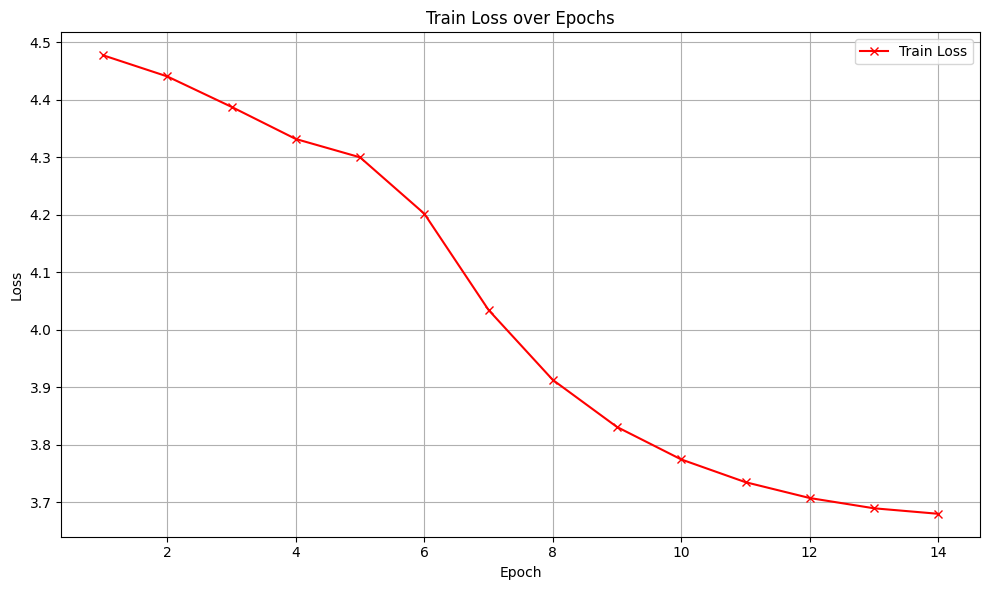

In [15]:
df = pd.read_csv("epoch_accuracy_logs/accuracy_log.csv")
df = df.dropna(subset=["train_loss"])
print("Epoch        Train Loss:")
print(df[["epoch", "train_loss"]])
plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss", color="red", marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>**Testing**</h1>

In [16]:
print(f"Test loader attrs shape: {next(iter(test_loader))[1].shape}")
print(f"all_class_attributes shape: {all_class_attributes.shape}")

Test loader attrs shape: torch.Size([16, 85])
all_class_attributes shape: torch.Size([50, 85])


In [17]:
# # Optional: Load class names if available
# with open('/kaggle/input/animals-with-attributes-2/Animals_with_Attributes2/classes.txt') as f:
#     class_names = [line.strip().split('\t')[1] for line in f]

# evaluate_zsl_test_accuracy_with_confusion(
#     model=model,
#     test_loader=test_loader,
#     all_class_attributes=all_class_attributes,
#     class_names=class_names  # or None if unavailable
# )